In [1]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

data_dir = Path('data')
enron_file = data_dir / 'enron_spam_data.zip'

raw_data = pd.read_csv(enron_file, compression='zip')
df = pd.DataFrame({
    'text': raw_data['Subject'].fillna('') + ' ' + raw_data['Message'].fillna(''),
    'label': (raw_data['Spam/Ham'] == 'spam').astype(int)
})

df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 0].drop_duplicates(subset='text')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'].values,
    df['label'].values,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(f"Dataset ready. Train size: {len(X_train_raw)}, Test size: {len(X_test_raw)}")

Dataset ready. Train size: 24369, Test size: 6093


In [2]:
def extract_handcrafted_features(texts):
    df_feat = pd.DataFrame()
    df_feat['text'] = texts
    df_feat['num_excl'] = [t.count('!') for t in texts]
    df_feat['num_quest'] = [t.count('?') for t in texts]
    df_feat['num_caps'] = [sum(1 for c in t if c.isupper()) for t in texts]
    df_feat['has_link'] = [1 if ('http' in t.lower() or 'www' in t.lower()) else 0 for t in texts]
    return df_feat

print("Extracting features from text...")
X_train_df = extract_handcrafted_features(X_train_raw)
X_test_df = extract_handcrafted_features(X_test_raw)
print("Feature extraction completed.")

Extracting features from text...
Feature extraction completed.


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('text_vec', CountVectorizer(stop_words='english', min_df=3, max_df=0.9), 'text'),
        ('numeric_scaler', MinMaxScaler(), ['num_excl', 'num_quest', 'num_caps', 'has_link'])
    ]
)

model_features = Pipeline([
    ('prep', preprocessor),
    ('clf', MultinomialNB(alpha=1.0))
])

In [4]:
from sklearn.metrics import classification_report

print("Training model with handcrafted features...")
model_features.fit(X_train_df, y_train)

print("Evaluating...")
y_pred = model_features.predict(X_test_df)

print("\n" + "=" * 55)
print("Classification Report (Exercise 2: Feature Engineering)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam'], digits=4))

Training model with handcrafted features...
Evaluating...

Classification Report (Exercise 2: Feature Engineering)
              precision    recall  f1-score   support

         Ham     0.9893    0.9837    0.9864      3182
        Spam     0.9822    0.9883    0.9853      2911

    accuracy                         0.9859      6093
   macro avg     0.9858    0.9860    0.9859      6093
weighted avg     0.9859    0.9859    0.9859      6093



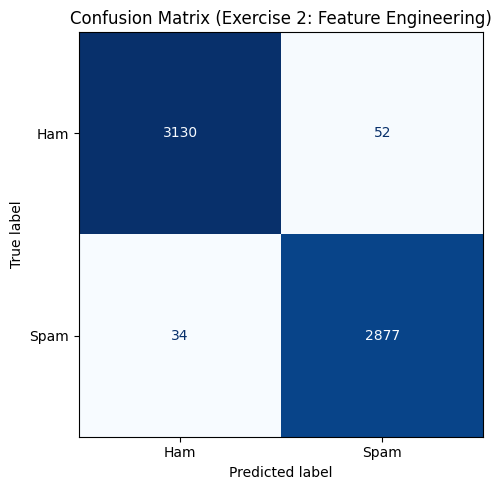

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix (Exercise 2: Feature Engineering)")
plt.tight_layout()
plt.show()